In [2]:
import pandas as pd
import re
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from xgboost import XGBRegressor
from sklearn.decomposition import PCA

In [3]:
df = pd.read_csv('./datasets/dataset_clean4.csv')
df

,index_k,R501,R502,R503,R504A,R504B,R504C,R601A,R601B1,R602A1,...,R702B_2,R702B_3,R702B_4,R702B_5,R702B_6,R702B_7,R702B_8,R702B_9,R702B_10,R702B_11
0,62.31,2,0,1,1,1,1,0,3.0,-1.0,...,0,0,0,0,0,0,0,0,0,0
1,72.21,3,0,1,1,1,1,1,4.0,1.0,...,0,0,0,0,0,0,0,0,0,0
2,70.80,3,0,1,1,1,1,0,1.0,-1.0,...,0,0,0,0,0,0,0,0,0,0
3,72.89,3,0,1,1,1,1,1,4.0,1.0,...,0,0,0,0,0,0,0,0,0,0
4,72.34,5,0,1,1,2,2,1,4.0,1.0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
74679,76.08,9,0,0,1,3,1,0,1.0,-1.0,...,0,0,0,0,0,1,0,0,0,0
74680,67.29,9,1,0,1,3,2,0,1.0,-1.0,...,0,0,0,0,0,0,0,0,0,0
74681,64.13,5,1,1,2,2,2,1,4.0,4.0,...,0,1,0,0,0,0,0,0,0,0
74682,71.23,5,1,0,1,1,1,0,3.0,-1.0,...,0,0,0,0,0,0,0,0,0,0


# EDA

In [4]:
def natural_sort_key(column_name):
    # Menggunakan regex untuk memisahkan string menjadi bagian-bagian angka (\d+) dan non-angka (\D+)
    # Filter(None, ...) akan menghilangkan string kosong yang mungkin dihasilkan oleh split
    parts = [int(text) if text.isdigit() else text.lower() for text in re.split(r'(\d+)', column_name)]
    return parts

# Mengambil daftar kolom dan mengurutkannya menggunakan kunci kustom
sorted_columns_natural_order = sorted(df.columns, key=natural_sort_key)

# Menerapkan urutan kolom yang baru ke DataFrame
df = df.reindex(sorted_columns_natural_order, axis=1)

## Info Data

In [5]:
df.describe()

,index_k,R501,R502,R503,R504A,R504B,R504C,R601A,R601B1,R602A1,...,R1611,R1612,R1613A,R1613B,R1613C,R1614,R1615,R1616,URUT,WEIGHT
count,74684.000000,74684.000000,74684.000000,74684.000000,74684.000000,74684.000000,74684.000000,74684.000000,74684.000000,74684.000000,...,74684.000000,74684.000000,74684.000000,74684.000000,74684.000000,74684.000000,74684.000000,74684.000000,74684.000000,74684.000000
mean,66.410889,4.006615,0.143712,0.462683,1.111831,1.933774,1.626105,0.714785,3.195289,3.603048,...,2.011421,3.070028,1.756387,-0.119276,0.779216,1.772722,3.496840,1.503254,37342.500000,934.529876
std,6.940839,1.956597,0.350800,0.498609,0.393634,0.932984,0.903802,0.451520,1.308585,5.421813,...,1.032286,1.091356,0.554728,1.340123,1.453005,0.881138,0.872296,0.986134,21559.558089,903.367661
min,9.480000,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,1.000000,-1.000000,...,1.000000,1.000000,1.000000,-1.000000,-1.000000,1.000000,1.000000,1.000000,1.000000,17.859985
25%,62.160000,3.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,1.000000,-1.000000,...,1.000000,2.000000,1.000000,-1.000000,-1.000000,1.000000,3.000000,1.000000,18671.750000,342.553009
50%,66.190000,4.000000,0.000000,0.000000,1.000000,2.000000,1.000000,1.000000,4.000000,1.000000,...,2.000000,3.000000,2.000000,-1.000000,1.000000,1.000000,4.000000,1.000000,37342.500000,624.806641
75%,70.500000,5.000000,0.000000,1.000000,1.000000,3.000000,2.000000,1.000000,4.000000,7.000000,...,2.000000,4.000000,2.000000,2.000000,2.000000,3.000000,4.000000,2.000000,56013.250000,1274.261597
max,100.000000,10.000000,1.000000,1.000000,4.000000,4.000000,4.000000,1.000000,4.000000,17.000000,...,4.000000,4.000000,3.000000,2.000000,3.000000,4.000000,4.000000,4.000000,74684.000000,14644.427734


Proses ini menangani data hilang karena sparse dan encoding data kategorical

# Encoding

In [6]:
df.shape

(74684, 223)

In [7]:
# Encoding kolom kategorikal nominal
kolom_kategorikal_nominal = [
    "R601B1", "R602A1", "R602A2", "R703B", "R902C", "R1201", "R1205", "R1608B", "R1613B"
]

kolom_kategorikal_ordinal = [
    "R501", "R504A", "R504B", "R504C", "R603", "R606", "R607", "R609A", "R609B", "R609C", "R701A", "R701B",
    "R704A", "R704B", "R704C", "R704D", "R704E", "R704F", "R704G", "R704H",
    "R706A", "R706B", "R706C", "R706D", "R706E", "R706F", "R706G", "R706H", "R706I", "R706J", "R707A", "R707B", "R707C",
    "R801A", "R801B", "R801C", "R801D", "R1001A", "R1001B", "R1001C", "R1101C", "R1104A", "R1104B", "R1104C", "R1105",
    "R1106A", "R1106B", "R1107A", "R1107B", "R1203", "R1204", "R1206A", "R1206B", "R1207", "R1208", "R1209",
    "R1301A", "R1301B", "R1301C", "R1303A", "R1303B", "R1303C", "R1305A", "R1305B", "R1305C", "R1305D",
    "R1401A", "R1401B", "R1401C", "R1401D", "R1403A", "R1403B", "R1403C", "R1405A", "R1405B", "R1405C",
    "R1407A", "R1407B", "R1409A", "R1411A", "R1411B", "R1411C", "R1602", "R1603", "R1604B",
    "R1605A", "R1605B", "R1605C", "R1605D", "R1605E", "R1606", "R1607A", "R1610", "R1611", "R1612",
    "R1613A", "R1613C", "R1614", "R1615", "R1616"
]

kolom_biner = [
    "R502", "R503", "R601A", "R602B", "R604A", "R604B", "R604C", "R604D", "R604E", "R604F", "R604G", "R608",
    "R702A", "R703A1", "R703A2", "R705A", "R705B1", "R705B2", "R705B3", "R705B4", "R705B5", "R705B6", "R902B1",
    "R902B2", "R902B3", "R902B4", "R902B5", "R1101A1", "R1101A2", "R1101A3", "R1101A4", "R1101A5", "R1101B1",
    "R1101B2", "R1101B3", "R1210A", "R1210B", "R1210C", "R1210D", "R1210E", "R1409B", "R1604A", "R1608A", "R1609A",
    "R1609B1", "R1609B2", "R1609B3", "R1609B4", "R1609B5", "R1609B6"
]

# sudah biner
kolom_kategorikal_encoded = [
    "R702B1", "R702B2", "R702B3", "R702B4", "R702B5", "R702B6", "R702B7", "R702B8", "R702B9", "R702B10", "R702B11",
    'R1607B_A', 'R1607B_B', 'R1607B_C', 'R1607B_D', 'R1607B_E', 'R1607B_F', 'R1607B_X',
    'R1609C_A', 'R1609C_B', 'R1609C_C', 'R1609C_D', 'R1609C_E', 'R1609C_F',
    'R1608C_A', 'R1608C_B', 'R1608C_C', 'R1608C_D', 'R1608C_E', 'R1608C_F',
]

# nilai 1 - 10
kolomscoring = [
    "R1003A", "R1003B", "R1003C", "R1003D", "R1003E", "R1003F", "R1003G", "R1003H", "R1003I", "R1003J",
    "R1004A", "R1004B", "R1004C", "R1004D", "R1004E", "R1004F",
    "R1002A", "R1002B", "R1002C", "R1002D", "R1002E", "R1002F", "R1002G", "R1002H", "R1002I", "R1002J"
]

kolomnominal = [
    "R1601A",
    "R1601B",
    "R902A",
    "R1202",
    "R901"
]

In [8]:
df[kolomnominal].describe()

,R1601A,R1601B,R902A,R1202,R901
count,74684.000000,74684.000000,74684.000000,74684.000000,74684.000000
mean,6.636602,5.073215,26.467408,75.005784,46.581722
std,3.600758,3.964253,16.120430,52.559595,19.479345
min,0.000000,0.000000,0.000000,3.000000,0.000000
25%,4.000000,2.000000,14.000000,45.000000,35.000000
50%,6.000000,5.000000,21.000000,63.000000,46.000000
75%,8.000000,7.000000,35.000000,90.000000,56.000000
max,50.000000,49.000000,98.000000,998.000000,98.000000


In [9]:
# Gabungkan semua kolom yang diharapkan (nominal + ordinal)
kolom_diharapkan = set(kolom_kategorikal_nominal + kolom_kategorikal_ordinal + kolom_biner + kolom_kategorikal_encoded + kolomnominal + kolomscoring)

print("Jumlah kolom yang diharapkan:", len(kolom_diharapkan)) 
print("Jumlah kolom asal:", len(df.columns)) 
# Ambil kolom yang ada di df
kolom_df = set(df.columns)

# Cari kolom yang ada di df tetapi tidak ada dalam daftar kolom_kategorikal
kolom_tambahan = kolom_df - kolom_diharapkan

# Tampilkan kolom tersebut
print("Jumlah kolom dalam df yang tidak ada dalam daftar :", len(kolom_tambahan))
print("Kolom dalam df yang tidak ada dalam daftar kategorikal:")
print(kolom_tambahan)

Jumlah kolom yang diharapkan: 220
Jumlah kolom asal: 223
Jumlah kolom dalam df yang tidak ada dalam daftar : 14
Kolom dalam df yang tidak ada dalam daftar kategorikal:
{'R702B_6', 'R702B_7', 'R702B_5', 'WEIGHT', 'URUT', 'index_k', 'R702B_3', 'R702B_2', 'R702B_11', 'R702B_4', 'R702B_9', 'R702B_8', 'R702B_10', 'R702B_1'}


In [10]:
kolom_diharapkan

{'R1001A',
 'R1001B',
 'R1001C',
 'R1002A',
 'R1002B',
 'R1002C',
 'R1002D',
 'R1002E',
 'R1002F',
 'R1002G',
 'R1002H',
 'R1002I',
 'R1002J',
 'R1003A',
 'R1003B',
 'R1003C',
 'R1003D',
 'R1003E',
 'R1003F',
 'R1003G',
 'R1003H',
 'R1003I',
 'R1003J',
 'R1004A',
 'R1004B',
 'R1004C',
 'R1004D',
 'R1004E',
 'R1004F',
 'R1101A1',
 'R1101A2',
 'R1101A3',
 'R1101A4',
 'R1101A5',
 'R1101B1',
 'R1101B2',
 'R1101B3',
 'R1101C',
 'R1104A',
 'R1104B',
 'R1104C',
 'R1105',
 'R1106A',
 'R1106B',
 'R1107A',
 'R1107B',
 'R1201',
 'R1202',
 'R1203',
 'R1204',
 'R1205',
 'R1206A',
 'R1206B',
 'R1207',
 'R1208',
 'R1209',
 'R1210A',
 'R1210B',
 'R1210C',
 'R1210D',
 'R1210E',
 'R1301A',
 'R1301B',
 'R1301C',
 'R1303A',
 'R1303B',
 'R1303C',
 'R1305A',
 'R1305B',
 'R1305C',
 'R1305D',
 'R1401A',
 'R1401B',
 'R1401C',
 'R1401D',
 'R1403A',
 'R1403B',
 'R1403C',
 'R1405A',
 'R1405B',
 'R1405C',
 'R1407A',
 'R1407B',
 'R1409A',
 'R1409B',
 'R1411A',
 'R1411B',
 'R1411C',
 'R1601A',
 'R1601B',
 'R1602',
 

In [11]:
for col in df.columns:
    median_value = df.loc[df[col] != -1, col].median()
    df[col] = df[col].replace(-1, median_value)

In [16]:
# ColumnTransformer dengan OneHotEncoder
preprocessor = ColumnTransformer(
    transformers=[
        ('onehot_nominal', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), kolom_kategorikal_nominal)
    ],
    remainder='passthrough'  # mempertahankan kolom lainnya tanpa perubahan
)
# Fit dan transform data
X_encoded = preprocessor.fit_transform(df)

# Ambil nama kolom hasil One-Hot Encoding
encoded_cols = preprocessor.named_transformers_['onehot_nominal'].get_feature_names_out(kolom_kategorikal_nominal)

# Ambil kolom yang bukan kategori
non_encoded_cols = [col for col in df.columns if col not in kolom_kategorikal_nominal]

# Buat DataFrame hasil encoding
df_encoded = pd.DataFrame(X_encoded, columns=list(encoded_cols) + non_encoded_cols)

# Tampilkan hasil
df_encoded.head()

,R601B1_1.0,R601B1_2.0,R601B1_3.0,R601B1_4.0,R602A1_1.0,R602A1_2.0,R602A1_3.0,R602A1_4.0,R602A1_5.0,R602A1_6.0,...,R1610,R1611,R1612,R1613A,R1613C,R1614,R1615,R1616,URUT,WEIGHT
0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,3.0,1.0,4.0,2.0,2.0,2.0,4.0,1.0,1.0,210.870377
1,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,...,4.0,1.0,4.0,2.0,2.0,2.0,4.0,2.0,2.0,210.870377
2,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,3.0,2.0,3.0,2.0,2.0,2.0,4.0,2.0,3.0,210.870377
3,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,...,4.0,1.0,4.0,2.0,2.0,2.0,4.0,2.0,4.0,210.870377
4,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,...,3.0,1.0,4.0,2.0,1.0,2.0,4.0,2.0,5.0,210.870377


In [13]:
df["R1003F"].describe()

count    74684.000000
mean         6.814806
std          2.025769
min          0.000000
25%          6.000000
50%          7.000000
75%          8.000000
max         10.000000
Name: R1003F, dtype: float64

In [14]:

print(df["R503"].value_counts(dropna=False))

R503
0    40129
1    34555
Name: count, dtype: int64


## ...

# Modeling and Feature Importance

In [64]:
df_encoded.describe()

,R601B1_1.0,R601B1_2.0,R601B1_3.0,R601B1_4.0,R602A1_1.0,R602A1_2.0,R602A1_3.0,R602A1_4.0,R602A1_5.0,R602A1_6.0,...,R1610,R1611,R1612,R1613A,R1613C,R1614,R1615,R1616,URUT,WEIGHT
count,72866.000000,72866.000000,72866.000000,72866.000000,72866.000000,72866.000000,72866.000000,72866.000000,72866.000000,72866.000000,...,72866.000000,72866.000000,72866.000000,72866.000000,72866.00000,72866.000000,72866.000000,72866.000000,72866.000000,72866.000000
mean,0.258145,0.003294,0.022974,0.715588,0.331362,0.009922,0.339665,0.001812,0.002594,0.026309,...,3.293676,2.010018,3.068029,1.754673,1.88052,1.775478,3.497598,1.500439,37289.465732,935.543062
std,0.437617,0.057297,0.149821,0.451137,0.470706,0.099116,0.473599,0.042524,0.050864,0.160052,...,1.008389,1.030454,1.092043,0.554410,0.53212,0.881310,0.871407,0.983697,21524.699304,901.490783
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,17.859985
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,3.000000,1.000000,2.000000,1.000000,2.00000,1.000000,3.000000,1.000000,18629.250000,343.513245
50%,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,4.000000,2.000000,3.000000,2.000000,2.00000,1.000000,4.000000,1.000000,37209.500000,626.721802
75%,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,...,4.000000,2.000000,4.000000,2.000000,2.00000,3.000000,4.000000,2.000000,55957.750000,1275.971069
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,4.000000,4.000000,4.000000,3.000000,3.00000,4.000000,4.000000,4.000000,74684.000000,14644.427734


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Misalnya data kamu bernama `df`
plt.figure(figsize=(6, 4))
sns.boxplot(y=df['index_k'], color='skyblue')
plt.title('Boxplot of index_k')
plt.ylabel('index_k')
plt.grid(True)
plt.show()


In [65]:
# Asumsikan kolommu bernama 'index_k'
Q1 = df_encoded['index_k'].quantile(0.25)
Q3 = df_encoded['index_k'].quantile(0.75)
IQR = Q3 - Q1

# Tentukan batas bawah dan atas
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filter data tanpa outlier
df_encoded = df_encoded[(df_encoded['index_k'] >= lower_bound) & (df_encoded['index_k'] <= upper_bound)]

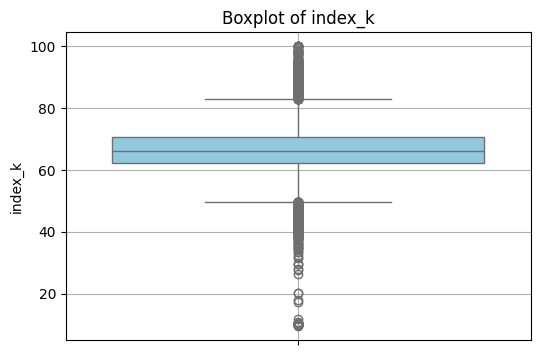

In [84]:
import matplotlib.pyplot as plt
import seaborn as sns

# Misalnya data kamu bernama `df`
plt.figure(figsize=(6, 4))
sns.boxplot(y=df['index_k'], color='skyblue')
plt.title('Boxplot of index_k')
plt.ylabel('index_k')
plt.grid(True)
plt.show()


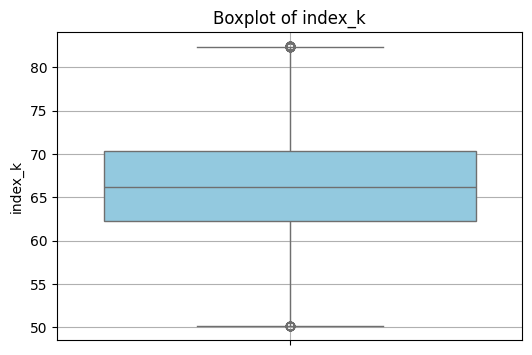

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Misalnya data kamu bernama `df`
plt.figure(figsize=(6, 4))
sns.boxplot(y=df_encoded['index_k'], color='skyblue')
plt.title('Boxplot of index_k')
plt.ylabel('index_k')
plt.grid(True)
plt.show()


In [66]:
# Fitur dan target
y = df_encoded['index_k']
sample_weight = df_encoded['WEIGHT']
sample_weight = sample_weight / np.mean(sample_weight)
X = df_encoded.drop(columns=['URUT','index_k', 'WEIGHT', "R702B_1", "R702B_2", "R702B_3", "R702B_4", "R702B_5", "R702B_6", "R702B_7", "R702B_8", "R702B_9", "R702B_10", "R702B_11"])

In [67]:
X

,R601B1_1.0,R601B1_2.0,R601B1_3.0,R601B1_4.0,R602A1_1.0,R602A1_2.0,R602A1_3.0,R602A1_4.0,R602A1_5.0,R602A1_6.0,...,R1609C_E,R1609C_F,R1610,R1611,R1612,R1613A,R1613C,R1614,R1615,R1616
0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,3.0,1.0,4.0,2.0,2.0,2.0,4.0,1.0
1,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,4.0,1.0,4.0,2.0,2.0,2.0,4.0,2.0
2,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,3.0,2.0,3.0,2.0,2.0,2.0,4.0,2.0
3,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,4.0,1.0,4.0,2.0,2.0,2.0,4.0,2.0
4,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,3.0,1.0,4.0,2.0,1.0,2.0,4.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
74679,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,4.0,2.0,1.0,2.0,2.0,3.0,1.0,1.0
74680,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,4.0,2.0,1.0,2.0,3.0,3.0,2.0,1.0
74681,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,4.0,2.0,2.0,1.0,2.0,3.0,4.0,2.0
74682,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,4.0,2.0,4.0,2.0,2.0,3.0,4.0,1.0


## Random Forest

In [68]:
rf_X_train, rf_X_test, rf_y_train, rf_y_test, weight_train, weight_test = train_test_split(
    X, y, sample_weight, test_size=0.3, random_state=42
)

In [69]:
rfr = RandomForestRegressor(n_estimators=100, random_state=42, max_depth=10, min_samples_leaf=5)
rfr.fit(rf_X_train, rf_y_train, sample_weight=weight_train)

RandomForestRegressor(max_depth=10, min_samples_leaf=5, random_state=42)

In [70]:
# --- 4. Prediksi pada Data Testing ---
rf_y_pred = rfr.predict(rf_X_test)

# --- 5. Evaluasi Model ---
mse = mean_squared_error(rf_y_test, rf_y_pred)
rmse = np.sqrt(mse) # Root Mean Squared Error
r2 = r2_score(rf_y_test, rf_y_pred)

print(f"\nMetrik Evaluasi Model:")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R2): {r2:.2f}")


Metrik Evaluasi Model:
Mean Squared Error (MSE): 25.32
Root Mean Squared Error (RMSE): 5.03
R-squared (R2): 0.31


In [71]:
feature_importances = rfr.feature_importances_
feature_names = X.columns
# Pastikan feature_names sesuai dengan jumlah fitur di X
if len(feature_names) != len(feature_importances):
    # Jika Anda memiliki data riil, pastikan kolom X_train memiliki nama kolom
    # Atau gunakan indeks fitur sebagai nama sementara
    feature_names_display = [f'fitur_{i}' for i in range(len(feature_importances))]
else:
    feature_names_display = feature_names

importance_df = pd.DataFrame({'Feature': feature_names_display, 'Importance': feature_importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

print("\n--- 50 Fitur Teratas Berdasarkan Importansi ---")
print(importance_df.head(50).to_string(index=False)) # .to_string(index=False) untuk membersihkan output




--- 50 Fitur Teratas Berdasarkan Importansi ---
Feature  Importance
 R1003F    0.200888
 R1002A    0.058411
 R1002C    0.046988
 R1003H    0.037640
   R501    0.033972
 R1003D    0.032471
 R1003G    0.030171
 R1002D    0.023044
 R1409B    0.017354
  R609A    0.016383
 R1002J    0.016248
 R1002E    0.014871
   R606    0.014443
 R1003A    0.014261
 R1004C    0.013932
 R1003J    0.013919
 R1004F    0.012370
 R1004B    0.011976
  R609B    0.009726
 R1002B    0.009429
 R1003I    0.009303
  R902A    0.008463
  R1202    0.008309
 R1003C    0.008172
 R1002F    0.008025
 R1003B    0.007991
 R1003E    0.007824
 R1002I    0.007430
   R901    0.007250
   R603    0.006850
 R1004D    0.006266
  R504C    0.006246
 R1004A    0.005943
  R1208    0.005755
 R1004E    0.005750
 R1405C    0.005682
 R1002H    0.005598
 R1605E    0.005381
 R1601B    0.005084
 R1002G    0.004994
 R1601A    0.004983
 R1605D    0.004793
 R1607A    0.004725
  R609C    0.004174
 R1001B    0.004037
 R1303A    0.003842
 R1106B    

In [72]:
print(importance_df.tail(20).to_string(index=False))

    Feature  Importance
  R703B_2.0    0.000068
    R1205_5    0.000061
  R703B_6.0    0.000058
    R1205_6    0.000050
      R706J    0.000023
    R1201_4    0.000021
R602A1_10.0    0.000018
 R601B1_2.0    0.000014
  R703B_3.0    0.000012
 R602A1_2.0    0.000009
R602A1_16.0    0.000005
 R602A1_4.0    0.000000
R602A1_11.0    0.000000
    R1205_2    0.000000
 R602A1_5.0    0.000000
    R1201_5    0.000000
R602A1_12.0    0.000000
     R1609A    0.000000
    R1609B6    0.000000
  R703B_4.0    0.000000


In [73]:
mostImportanceFeature = importance_df.head(50)['Feature'].tolist()
# mostImportanceFeature
nrf_X_train, nrf_X_test, nrf_y_train, nrf_y_test, weight_train, weight_test = train_test_split(
    X[mostImportanceFeature], y, sample_weight, test_size=0.3, random_state=42
)



In [74]:
X[mostImportanceFeature].shape

(72616, 50)

In [75]:
nrfr = RandomForestRegressor(n_estimators=100, random_state=42, max_depth=10, min_samples_leaf=5)
nrfr.fit(nrf_X_train, nrf_y_train, sample_weight=weight_train)

RandomForestRegressor(max_depth=10, min_samples_leaf=5, random_state=42)

In [76]:
# --- 4. Prediksi pada Data Testing ---
nrf_y_pred = nrfr.predict(nrf_X_test)

# --- 5. Evaluasi Model ---
nrf_mse = mean_squared_error(nrf_y_test, nrf_y_pred)
nrf_rmse = np.sqrt(nrf_mse) # Root Mean Squared Error
nrf_r2 = r2_score(nrf_y_test, nrf_y_pred)

print(f"\nMetrik Evaluasi Model:")
print(f"Mean Squared Error (nrf_MSE): {nrf_mse:.2f}")
print(f"Root Mean Squared Error (nrf_RMSE): {nrf_rmse:.2f}")
print(f"R-squared (R2): {nrf_r2:.2f}")


Metrik Evaluasi Model:
Mean Squared Error (nrf_MSE): 25.40
Root Mean Squared Error (nrf_RMSE): 5.04
R-squared (R2): 0.31


## XGB

In [77]:
xgb_X_train, xgb_X_test, xgb_y_train, xgb_y_test, weight_train, weight_test = train_test_split(
    X, y, sample_weight, test_size=0.3, random_state=42
)

In [78]:
# 3. Buat model XGBoost Regressor
xgb = XGBRegressor( random_state=42)
# 4. Latih model
xgb.fit(xgb_X_train, xgb_y_train)
# 5. Prediksi
xgb_y_pred = xgb.predict(xgb_X_test)
# 6. Evaluasi model
mse = mean_squared_error(xgb_y_test, xgb_y_pred)
r2 = r2_score(xgb_y_test, xgb_y_pred)

print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R-squared (R2): {r2:.2f}")

Mean Squared Error (MSE): 23.66
R-squared (R2): 0.36


In [79]:
xgb_feature_importances = xgb.feature_importances_
xgb_feature_names = xgb_X_train.columns

# Buat DataFrame dan ambil 50 fitur teratas
xgb_importance_df = pd.DataFrame({
    'Feature': xgb_feature_names,
    'Importance': xgb_feature_importances
}).sort_values(by='Importance', ascending=False)

xgb_mostImportanceFeature = xgb_importance_df.head(50)['Feature'].tolist()

In [80]:
nxgb_X_train, nxgb_X_test, nxgb_y_train, nxgb_y_test, weight_train, weight_test = train_test_split(
    X[xgb_mostImportanceFeature], y, sample_weight, test_size=0.3, random_state=42
)

In [81]:
# 3. Buat model XGBoost Regressor
nxgb = XGBRegressor( random_state=42)
# 4. Latih model
nxgb.fit(nxgb_X_train, nxgb_y_train)
# 5. Prediksi
nxgb_y_pred = nxgb.predict(nxgb_X_test)
# 6. Evaluasi model
mse = mean_squared_error(nxgb_y_test, nxgb_y_pred)
r2 = r2_score(nxgb_y_test, nxgb_y_pred)
rmse = np.sqrt(mse)

print(f"\nMetrik Evaluasi Model:")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R-squared (R2): {r2:.2f}")


Metrik Evaluasi Model:
Root Mean Squared Error (RMSE): 4.96
Mean Squared Error (MSE): 24.62
R-squared (R2): 0.33


# PCA

In [57]:
pca = PCA(n_components=5)
X_pca = pca.fit_transform(X)

In [58]:
print(f"Jumlah komponen utama: {pca.n_components_}")
print("Rasio variansi yang dijelaskan oleh tiap komponen:")
print(pca.explained_variance_ratio_)


Jumlah komponen utama: 5
Rasio variansi yang dijelaskan oleh tiap komponen:
[9.99992289e-01 5.93306896e-06 8.56082843e-07 5.12687197e-07
 5.14250551e-08]


In [48]:
import numpy as np
import pandas as pd

# Ambil komponen dan nama fitur
components = pca.components_  # shape: (n_components, n_features)
feature_names = X.columns     # nama-nama fitur asli

# Ambil 5 fitur teratas (dengan kontribusi terbesar) per komponen
top_features_per_component = {}

for i, component in enumerate(components):
    component_number = f'PC{i+1}'
    
    # Ambil indeks fitur dengan kontribusi absolut tertinggi
    top_indices = np.abs(component).argsort()[::-1][:15]
    
    # Buat DataFrame mini untuk komponen ini
    top_features = [(feature_names[j], component[j]) for j in top_indices]
    
    # Simpan ke dictionary
    top_features_per_component[component_number] = top_features

# Tampilkan hasil
for pc, features in top_features_per_component.items():
    print(f"\n{pc} paling dipengaruhi oleh:")
    for fname, weight in features:
        print(f"  {fname:<30} kontribusi: {weight:.4f}")



PC1 paling dipengaruhi oleh:
  URUT                           kontribusi: 1.0000
  R1202                          kontribusi: -0.0001
  R901                           kontribusi: -0.0000
  R1601A                         kontribusi: -0.0000
  R1601B                         kontribusi: -0.0000
  R1206B                         kontribusi: 0.0000
  R902A                          kontribusi: 0.0000
  R1002J                         kontribusi: 0.0000
  R1001C                         kontribusi: -0.0000
  R1004A                         kontribusi: 0.0000
  R1002I                         kontribusi: 0.0000
  R1607A                         kontribusi: -0.0000
  R1004D                         kontribusi: -0.0000
  R1002H                         kontribusi: 0.0000
  R1003F                         kontribusi: 0.0000


In [49]:
# 2. Split train-test
pca_X_train, pca_X_test, pca_y_train, pca_y_test, weight_train, weight_test = train_test_split(X_pca , y, sample_weight, test_size=0.2, random_state=42)


In [50]:
# 3. Buat model XGBoost Regressor
pca_xgb = XGBRegressor( random_state=42)
# 4. Latih model
pca_xgb.fit(xgb_X_train, xgb_y_train)
# 5. Prediksi
pca_xgb_y_pred = pca_xgb.predict(xgb_X_test)
# 6. Evaluasi model
mse = mean_squared_error(xgb_y_test, pca_xgb_y_pred)
r2 = r2_score(xgb_y_test, xgb_y_pred)

print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R-squared (R2): {r2:.2f}")

Mean Squared Error (MSE): 23.17
R-squared (R2): 0.39


# LassoCV

In [61]:
from sklearn.linear_model import LassoCV
lasso = LassoCV(cv=5)
lasso.fit(X, y)
selected_features = X.columns[(lasso.coef_ != 0)]
X_lasso = X[selected_features]

In [62]:
selected_features.shape

(2,)

In [63]:
selected_features

Index(['R1202', 'URUT'], dtype='object')

In [77]:
# 2. Split train-test
lasso_X_train, lasso_X_test, lasso_y_train, lasso_y_test, weight_train, weight_test = train_test_split(X_lasso , y, sample_weight, test_size=0.2, random_state=42)

In [78]:
# 3. Buat model XGboost Regressor
lasso_xgb = XGBRegressor( random_state=42)
# 4. Latih model
lasso_xgb.fit(lasso_X_train, lasso_y_train)
# 5. Prediksi
lasso_xgb_y_pred = lasso_xgb.predict(lasso_X_test)
# 6. Evaluasi model
mse = mean_squared_error(lasso_y_test, lasso_xgb_y_pred)
r2 = r2_score(lasso_y_test, lasso_xgb_y_pred)

print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R-squared (R2): {r2:.2f}")

Mean Squared Error (MSE): 35.04
R-squared (R2): 0.07


# Recursive Feature Elimination (RFE)

In [79]:
from sklearn.feature_selection import RFE
from sklearn.linear_model import LinearRegression

model = LinearRegression()
rfe = RFE(estimator=model, n_features_to_select=50)
VX_rfe = rfe.fit_transform(X, y)
selected_columns = X.columns[rfe.support_]


In [80]:
X_rfe = X[selected_columns]
# 2. Split train-test
rfe_X_train, rfe_X_test, rfe_y_train, rfe_y_test, weight_train, weight_test = train_test_split(X_rfe , y, sample_weight, test_size=0.2, random_state=42)

In [81]:
# 3. Buat model XGBoost Regressor
rfe_xgb = XGBRegressor( random_state=42)
# 4. Latih model
rfe_xgb.fit(rfe_X_train, rfe_y_train)
# 5. Prediksi
rfe_xgb_y_pred = rfe_xgb.predict(rfe_X_test)
# 6. Evaluasi model
mse = mean_squared_error(rfe_y_test, rfe_xgb_y_pred)
r2 = r2_score(rfe_y_test, rfe_xgb_y_pred)

print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R-squared (R2): {r2:.2f}")

Mean Squared Error (MSE): 36.36
R-squared (R2): 0.03


In [82]:
from sklearn.linear_model import HuberRegressor
from sklearn.datasets import make_regression
import numpy as np

# Generate synthetic data with outliers
# X, y = make_regression(n_samples=100, n_features=1, noise=10)
# y[::10] += 100  # Add outliers

# Fitur dan target
y = df_encoded['index_k']
sample_weight = df_encoded['WEIGHT']
sample_weight = sample_weight / np.mean(sample_weight)
X = df_encoded.drop(columns=['index_k', 'WEIGHT', "R702B1", "R702B2", "R702B3", "R702B4", "R702B5", "R702B6", "R702B7", "R702B8", "R702B9", "R702B10", "R702B11"])
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=10)
X_pca = pca.fit_transform(X)

# 2. Split train-test
X_train, X_test, y_train, y_test, weight_train, weight_test = train_test_split(X_pca , y, sample_weight, test_size=0.2, random_state=42)

# rf_X_train, rf_X_test, rf_y_train, rf_y_test, weight_train, weight_test = train_test_split(
#     X, y, sample_weight, test_size=0.3, random_state=42
# )


# Fit Huber Regressor
huber = HuberRegressor().fit(X_train, y_train, sample_weight=weight_train)

# Coefficient and intercept
print("Intercept:", huber.intercept_)
print("Coef:", huber.coef_)

Intercept: 26.844236755941825
Coef: [-1.59214097e-04  2.28259052e-01 -1.97339891e-01  3.46512051e-01
  3.56888586e+00  6.94802733e+00  9.81899482e-01  3.62840355e+00
  2.07362301e+00 -5.34344085e+00]


c:\Users\ASUS\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_huber.py:342: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


In [83]:
explained_var = pca.explained_variance_ratio_.cumsum()
print("Cumulative explained variance:", explained_var)

Cumulative explained variance: [0.99999229 0.99999822 0.99999908 0.99999959 0.99999964 0.99999968
 0.99999972 0.99999974 0.99999976 0.99999977]


In [84]:
y_pred = huber.predict(X_test)

# 5. Evaluasi
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

# 6. Print hasil
print(f"R-squared (R²): {r2:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")

R-squared (R²): -88.2094
Mean Absolute Error (MAE): 48.6851
Mean Squared Error (MSE): 3360.1276
Root Mean Squared Error (RMSE): 57.9666
